# Homework 4 — **Part 4 (Visualization) + Part 5 (Interpretation)**  
U.S. Flight Delays — Monthly Dataset (**Cancellation causes**)

## Data Source

**Original dataset:** [Flight Delay and Cancellation Dataset (2019-2023)](https://www.kaggle.com/datasets/patrickzel/flight-delay-and-cancellation-dataset-2019-2023?resource=download) from Kaggle
- Created by Patrick Zelazko
- Source: U.S. Bureau of Transportation Statistics (BTS)
- Coverage: January 2019 - August 2023
- Original size: 3 million flight records

**Dataset processing for this homework:**
The original dataset has been preprocessed for educational use:
1. **Downsampled** from 3M rows to ~15k rows using stratified sampling (preserves temporal patterns)
2. **Aggregated** to monthly level with computed statistics
3. **Enhanced** with cancellation cause percentages from BTS cancellation codes

This preprocessing reduces file size and computation time while maintaining the ability to analyze seasonal patterns and trends.

---

## Dataset Used in This Notebook

**File:** `flights_monthly_ready.csv` (student-ready monthly aggregated data)

**Columns:**
- `ym, year, month, flights` - temporal information and flight counts
- `dep_delayed, arr_delayed, dep_delay_rate, arr_delay_rate` - delay metrics
- `dep_delay_hours_mean, dep_delay_hours_std` - departure delay statistics
- `cancelled_total, cancel_carrier_pct, cancel_weather_pct, cancel_nas_pct, cancel_security_pct` - cancellation causes


### ANSWER

## Instructions

---

---

<font size=6 color="#009600">&#9998;</font> *Put your personal academic integrity statement here.*

---

## Setup

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

DATA_PATH = "flights_monthly_ready.csv"  # change if needed
m = pd.read_csv(DATA_PATH, parse_dates=["ym"])
m.head()


,ym,year,month,flights,dep_delayed,arr_delayed,dep_delay_rate,arr_delay_rate,dep_delay_hours_mean,dep_delay_hours_std,cancelled_total,cancel_carrier_pct,cancel_weather_pct,cancel_nas_pct,cancel_security_pct
0,2019-01-01,2019,1,267,38,51,14.232210,19.101124,0.553153,0.831444,7,14.285714,71.428571,14.285714,0.0
1,2019-02-01,2019,2,267,63,65,23.595506,24.344569,0.644136,1.000452,8,12.500000,75.000000,12.500000,0.0
2,2019-03-01,2019,3,267,42,38,15.730337,14.232210,0.429412,0.563088,6,66.666667,33.333333,0.000000,0.0
3,2019-04-01,2019,4,267,47,41,17.602996,15.355805,0.540230,0.625660,9,11.111111,77.777778,11.111111,0.0
4,2019-05-01,2019,5,267,69,66,25.842697,24.719101,0.870388,1.136079,10,50.000000,50.000000,0.000000,0.0


<a id="part_4"></a>

## Part 4 — Visualization

&#9989;&nbsp; **Part 4.1 (4 points)** **Calculate** the monthly **departure delay rate** and **arrival delay rate** from counts and verify against the columns.
- `dep_delay_rate = 100 * dep_delayed / flights`  
- `arr_delay_rate = 100 * arr_delayed / flights`

**Print** `ym, dep_delay_rate, arr_delay_rate` for the first 12 months.


<font size=6 color="#009600">&#9998;</font> *Put your answer here (1–2 sentences): Do your computed rates match the columns?*

In [18]:
### ANSWER
check = m.copy()
check["dep_delay_rate_calc"] = 100 * check["dep_delayed"] / check["flights"]
check["arr_delay_rate_calc"] = 100 * check["arr_delayed"] / check["flights"]
cols = ["ym","dep_delay_rate","dep_delay_rate_calc","arr_delay_rate","arr_delay_rate_calc"]
check.loc[:, cols].head(12)


,ym,dep_delay_rate,dep_delay_rate_calc,arr_delay_rate,arr_delay_rate_calc
0,2019-01-01,14.232210,14.232210,19.101124,19.101124
1,2019-02-01,23.595506,23.595506,24.344569,24.344569
2,2019-03-01,15.730337,15.730337,14.232210,14.232210
3,2019-04-01,17.602996,17.602996,15.355805,15.355805
4,2019-05-01,25.842697,25.842697,24.719101,24.719101
5,2019-06-01,23.220974,23.220974,22.471910,22.471910
6,2019-07-01,20.599251,20.599251,20.224719,20.224719
7,2019-08-01,18.726592,18.726592,14.606742,14.606742
8,2019-09-01,13.108614,13.108614,14.981273,14.981273
9,2019-10-01,14.981273,14.981273,16.104869,16.104869


&#9989;&nbsp; **Part 4.2 (6 points)** **Visualize** the monthly **departure delay rate** and **arrival delay rate** as **line plots** over time on the **same figure**.


<font size=6 color="#009600">&#9998;</font> *Put your answer here (1 sentence): Which month is worst for each rate?*

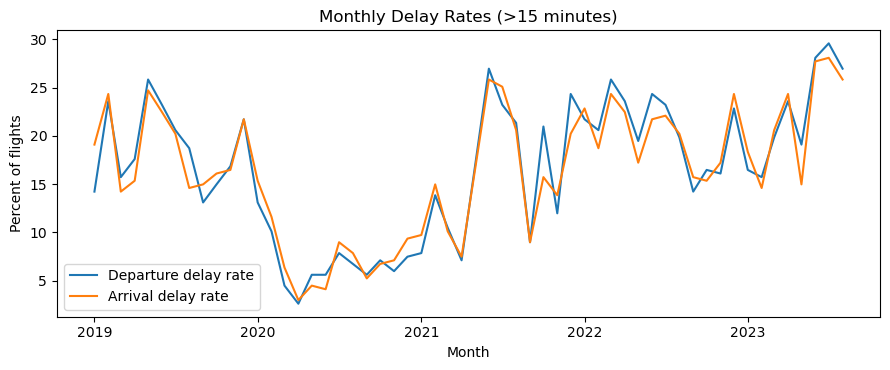

In [19]:
### ANSWER
plt.figure(figsize=(9,3.8))
plt.plot(m["ym"], m["dep_delay_rate"], label="Departure delay rate")
plt.plot(m["ym"], m["arr_delay_rate"], label="Arrival delay rate")
plt.title("Monthly Delay Rates (>15 minutes)")
plt.xlabel("Month"); plt.ylabel("Percent of flights")
plt.legend()
plt.tight_layout()
plt.show()


&#9989;&nbsp; **Part 4.3 (6 points)** **Visualize** the **average** and **standard deviation** of **departure delaying hours** for every month.

> Because the monthly file contains **aggregated** statistics (`dep_delay_hours_mean`, `dep_delay_hours_std`) rather than raw per‑flight values, use a **mean±std error‑bar chart** (a traditional boxplot would require raw values).

**How to create an error bar chart:**

Use `plt.errorbar()` to show mean values with error bars representing standard deviation:

```python
plt.errorbar(x, y, yerr=error, fmt='o')
```

**Parameters:**
- `x`: x-axis values (e.g., dates/months)
- `y`: y-axis values (e.g., mean values)
- `yerr`: error bars (e.g., standard deviation)
- `fmt='o'`: format string - `'o'` creates points/markers, can also use `'o-'` for points connected by lines


The error bars extend vertically from (mean - std) to (mean + std), showing the variability in the data.


<font size=6 color="#009600">&#9998;</font> *Put your answer here (1 sentence): Which months have the largest typical delays and variability?*

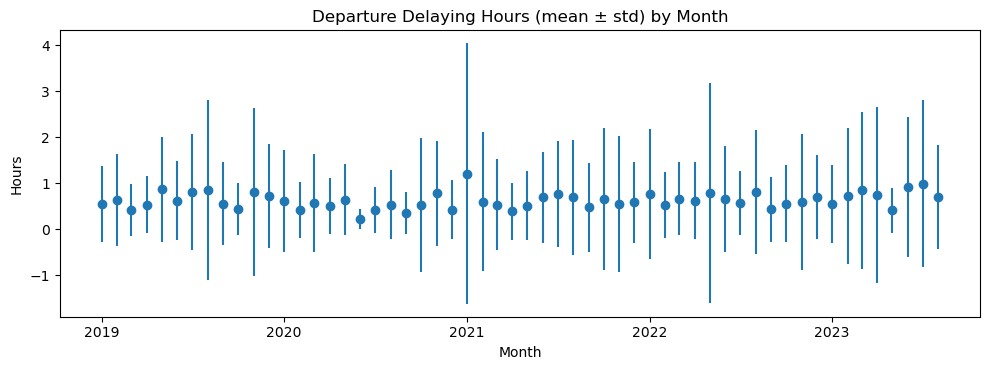

In [20]:
### ANSWER
plt.figure(figsize=(10,3.8))
plt.errorbar(m["ym"], m["dep_delay_hours_mean"], yerr=m["dep_delay_hours_std"], fmt='o')
plt.title("Departure Delaying Hours (mean ± std) by Month")
plt.xlabel("Month"); plt.ylabel("Hours")
plt.tight_layout()
plt.show()


&#9989;&nbsp; **Part 4.4 (8 points)** **Cancellation cause percentages by month** — make a **stacked area** (or stacked bars) using:
`cancel_carrier_pct, cancel_weather_pct, cancel_nas_pct, cancel_security_pct`.

> These are the **shares of cancellations** by cause (DOT/BTS: A=Carrier, B=Weather, C=NAS, D=Security).

**How to create a stacked area chart:**

Use `plt.stackplot()` to show how different categories contribute to a total over time:

```python
plt.stackplot(x, y1, y2, y3, ..., labels=['Category 1', 'Category 2', ...])
```

**Parameters:**
- `x`: x-axis values (e.g., dates/months) - shared by all categories
- `y1, y2, y3, ...`: y-axis values for each category (one array per category)
- `labels`: list of category names for the legend

**Key Features:**
- Each area is **stacked on top** of the previous one
- The **height of each colored band** represents that category's value
- The **total height** at any point shows the sum of all categories
- Perfect for showing **proportions** or **compositions** that add up to 100%

**Reading the chart:**
- Bottom area = first category (e.g., y1)
- Each band above = next category stacked on top
- Top edge = cumulative total (should be ~100% for percentages)


<font size=6 color="#009600">&#9998;</font> *Put your answer here (2 sentences): Which causes tend to rise in winter vs. summer?*

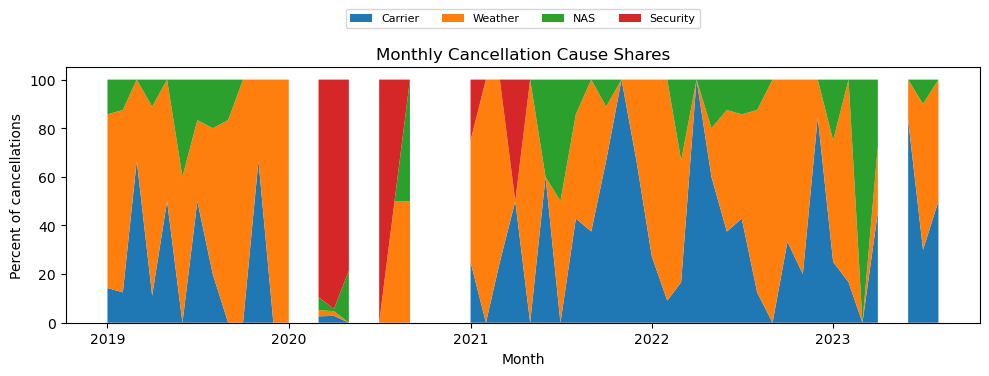

In [21]:
### ANSWER
cause_cols = ["cancel_carrier_pct","cancel_weather_pct","cancel_nas_pct","cancel_security_pct"]

plt.figure(figsize=(10,4))
plt.stackplot(m["ym"], m["cancel_carrier_pct"],m["cancel_weather_pct"],m["cancel_nas_pct"],m["cancel_security_pct"],
              labels=["Carrier","Weather","NAS","Security"])
plt.title("Monthly Cancellation Cause Shares")
plt.xlabel("Month"); plt.ylabel("Percent of cancellations")
plt.legend(ncol=4, fontsize=8, loc="upper center", bbox_to_anchor=(0.5,1.25))
plt.tight_layout()
plt.show()


<a id="part_5"></a>

## Part 5 — Interpretation

&#9989;&nbsp; **Part 5.1 (4 points)** **Best vs. worst months** for **departure** and **arrival** delay rates.  
Identify the **highest** and **lowest** months for each rate and **quantify** the values and **difference** (in percentage points).

<font size=6 color="#009600">&#9998;</font> *Put your answer here (2–3 sentences).*

In [22]:
### ANSWER
def top_bottom(col):
    top = m.loc[m[col].idxmax(), ["ym", col]]
    bot = m.loc[m[col].idxmin(), ["ym", col]]
    diff = float(top[col] - bot[col])
    print(f"{col}:")
    print(f"  Highest: {top['ym'].strftime('%Y-%m')} = {top[col]:.2f}%")
    print(f"  Lowest : {bot['ym'].strftime('%Y-%m')} = {bot[col]:.2f}%")
    print(f"  Difference: {diff:.2f} percentage points\n")

top_bottom("dep_delay_rate")
top_bottom("arr_delay_rate")


dep_delay_rate:
  Highest: 2023-07 = 29.59%
  Lowest : 2020-04 = 2.62%
  Difference: 26.97 percentage points

arr_delay_rate:
  Highest: 2023-07 = 28.09%
  Lowest : 2020-04 = 3.00%
  Difference: 25.09 percentage points



&#9989;&nbsp; **Part 5.2 (4 points)** **Do departure and arrival delay rates move together?**  
Compute the **correlation** between `dep_delay_rate` and `arr_delay_rate` and describe the strength **in one sentence**.

<font size=6 color="#009600">&#9998;</font> *Put your answer here (1–2 sentences).*

In [23]:
### ANSWER
corr = m["dep_delay_rate"].corr(m["arr_delay_rate"])
print(f"Correlation(dep, arr) = {corr:.3f}")



Correlation(dep, arr) = 0.966


&#9989;&nbsp; **Part 5.3 (6 points)** **How large and how variable are departure delays?**  
Using `dep_delay_hours_mean` and `dep_delay_hours_std`, list the **top two months** with the **largest mean** and the **largest std**; interpret briefly.

<font size=6 color="#009600">&#9998;</font> *Put your answer here (2–3 sentences).*

In [24]:
### ANSWER
top_mean = m.nlargest(2, "dep_delay_hours_mean")[["ym","dep_delay_hours_mean"]]
top_std  = m.nlargest(2, "dep_delay_hours_std")[["ym","dep_delay_hours_std"]]

print("Top-2 months by mean delaying hours:")
print(top_mean.to_string(index=False))
print("\nTop-2 months by std of delaying hours:")
print(top_std.to_string(index=False))


Top-2 months by mean delaying hours:
        ym  dep_delay_hours_mean
2021-01-01              1.213030
2023-07-01              0.991393

Top-2 months by std of delaying hours:
        ym  dep_delay_hours_std
2021-01-01             2.826378
2022-05-01             2.389969


&#9989;&nbsp; **Part 5.4 (6 points)** **Winter vs Summer cancellation causes comparison**.  

Compare cancellation causes between a **typical winter month** and a **typical summer month**:
- Find the month with the **highest `cancel_weather_pct`** (likely winter)
- Find the month with the **lowest `cancel_weather_pct`** (likely summer)

For each of these two months, display:
- The month (`ym`)
- All four cancellation cause percentages: `cancel_carrier_pct`, `cancel_weather_pct`, `cancel_nas_pct`, `cancel_security_pct`

Then describe which cause(s) are higher in winter vs summer and give **one plausible explanation** for the weather pattern.


<font size=6 color="#009600">&#9998;</font> *Put your answer here (2–3 sentences).*

**What to include in your answer:**
1. **State the two months** you found and their weather cancellation percentages
2. **Compare the causes:** Which cause(s) are higher in the winter month? Which are higher in the summer month?
3. **Explain why weather cancellations differ:** Why would weather cause more cancellations in winter than summer? (Think about: snow, ice, storms, visibility, extreme temperatures, etc.)

**Example structure:**
"The month with highest weather cancellations was [month] with [X]% weather-related cancellations, while [month] had only [Y]% weather cancellations. In the winter month, [cause] was the dominant factor at [Z]%, compared to the summer month where [cause] was higher at [W]%. This pattern makes sense because winter weather conditions such as [specific weather phenomenon] are more likely to ground flights than typical summer conditions."

In [25]:
### ANSWER
# Columns to display
cause_cols = ["ym", "cancel_carrier_pct", "cancel_weather_pct", "cancel_nas_pct", "cancel_security_pct"]

# Find month with HIGHEST weather cancellations (winter pattern)
highest_weather_idx = m["cancel_weather_pct"].idxmax()
winter_month = m.loc[highest_weather_idx, cause_cols]

# Find month with LOWEST weather cancellations (summer pattern)
lowest_weather_idx = m["cancel_weather_pct"].idxmin()
summer_month = m.loc[lowest_weather_idx, cause_cols]

print("Month with HIGHEST weather cancellations (winter):")
print(winter_month)
print("\nMonth with LOWEST weather cancellations (summer):")
print(summer_month)


Month with HIGHEST weather cancellations (winter):
ym                     2019-10-01 00:00:00
cancel_carrier_pct                     0.0
cancel_weather_pct                   100.0
cancel_nas_pct                         0.0
cancel_security_pct                    0.0
Name: 9, dtype: object

Month with LOWEST weather cancellations (summer):
ym                     2020-05-01 00:00:00
cancel_carrier_pct                     0.0
cancel_weather_pct                     0.0
cancel_nas_pct                   21.428571
cancel_security_pct              78.571429
Name: 16, dtype: object


## Congratulations, you're done!